In [1]:
%pip install -r ../requirements.txt
# pip install --force-reinstall numpy==1.18.5


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, shutil, zipfile, requests

url = "https://github.com/francescopausellii/uniform-coloring-ai/releases/download/v1.0/emnist.zip"
src = "../emnist.zip"
dst = os.path.expanduser("~/.cache/emnist/emnist.zip")

os.makedirs(os.path.dirname(dst), exist_ok=True)

# download se non esiste o è corrotto
if not os.path.exists(src) or not zipfile.is_zipfile(src):
    print("Scarico EMNIST...")
    with open(src, "wb") as f:
        f.write(requests.get(url).content)

# copia in cache
shutil.copy(src, dst)


'/home/francesco/.cache/emnist/emnist.zip'

In [ ]:
import numpy as np
import pandas as pd
import keras
from keras import layers
import cv2 as cv
from matplotlib import pyplot as plt

# Percorso modelli (relativo a notebooks/)
MODELS_DIR = "../models/"

# Durata del training (in epoche)
TRAINING_EPOCHS = 25

Forma train_images:  (112800, 28, 28)
Forma dell'immagine: (28, 28)
Max = 255   Min = 0
45


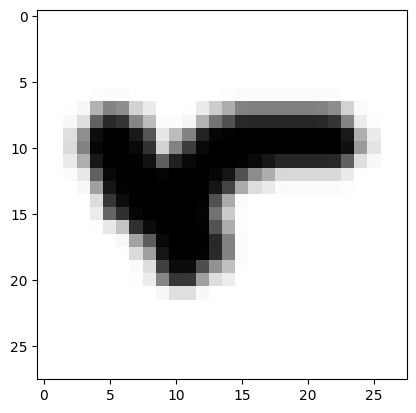

In [4]:
from emnist import extract_training_samples
from emnist import extract_test_samples

# x_train conterrà le matrici dei pixel delle immagini.
# y_train conterrà le etichette corrispondenti a ciascuna immagine.
x_train, y_train = extract_training_samples("balanced")

# Valutazione performance del modello
# su dati mai visti durante l'addestramento.
x_test, y_test = extract_test_samples("balanced")

# print forma dataset
print("Forma train_images: ", x_train.shape)
# forma immagine
print("Forma dell'immagine:", x_train[0].shape)

# print range valori pixel immagini
print("Max =", np.max(x_train), "  Min =", np.min(x_train))

# visualizzazione dataset

index = 0

plt.imshow(x_train[index], cmap=plt.cm.binary)
print(y_train[index])

In [5]:
# tutte le labels o valori presenti nel dataset scelto
ALL_LABELS = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 
          'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
          'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']

# lettere scelte per filtrare il dataset 
SELECTED_LABELS = ['B', 'G', 'T', 'Y']  

def filterDataset(X_data, y_data):
    # Controllo tipo etichette
    assert y_data.dtype == np.uint8
    classes = ALL_LABELS
    new_data_size = 0
    for recordIndex in range(0, y_data.shape[0]):
        currentLabel = classes[y_data[recordIndex]]
        if currentLabel in SELECTED_LABELS:
            new_data_size += 1

    new_X_data = np.zeros((new_data_size, 28, 28), dtype = X_data.dtype)
    new_y_data = np.zeros((new_data_size,), dtype = np.uint8)

    new_data_index = 0
    for recordIndex in range(0, y_data.shape[0]):
        currentLabel = classes[y_data[recordIndex]]

        if currentLabel not in SELECTED_LABELS:
            continue
        
        new_X_data[new_data_index] = X_data[recordIndex]
        new_y_data[new_data_index] = SELECTED_LABELS.index(currentLabel)
        new_data_index += 1
    
    assert new_data_index == new_X_data.shape[0]
    return (new_X_data, new_y_data)

Filtraggio dataset per tenere solo le lettere che ci interessano

In [6]:
(x_train_filter, y_train_filter) = filterDataset(x_train, y_train)
(x_test_filter, y_test_filter) = filterDataset(x_test, y_test)

# normalizzazione per calcolo dei pesi più veloce
x_train_filter = x_train_filter / np.max(x_train_filter)
x_test_filter = x_test_filter / np.max(x_test_filter)

# Stampa informazioni dataset filtrato
print("Train:", x_train_filter.shape, " Test:", x_test_filter.shape)

# Stampa distribuzione classi nel dataset filtrato
# Quante immagini per ciascuna classe sono presenti nel dataset di addestramento filtrato
print(
    "Distribuzione classi train:",
    {
        SELECTED_LABELS[k]: int(v)
        for k, v in zip(*np.unique(y_train_filter, return_counts=True))
    },
)

Train: (9600, 28, 28)  Test: (1600, 28, 28)
Distribuzione classi train: {'B': 2400, 'G': 2400, 'T': 2400, 'Y': 2400}


T


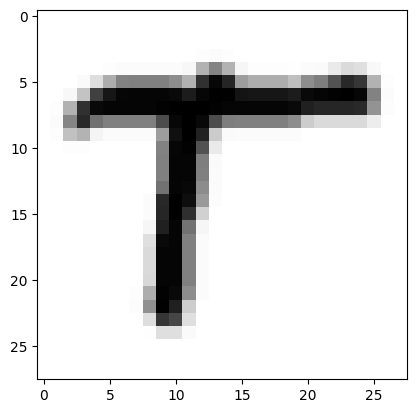

In [7]:
# visualizzazione dataset filtrato
index = 0

plt.imshow(x_train_filter[index], cmap=plt.cm.binary)
print(SELECTED_LABELS[y_train_filter[index]])

# Creazione Modello

Modello: MLP (fully-connected)

Un MLP non ha l'invarianza spaziale di una CNN: ogni pixel è un input indipendente, quindi una lettera leggermente spostata/ruotata/scalata rispetto agli esempi EMNIST produce attivazioni diverse.
Per compensare si usa la **data augmentation**: rotazioni, traslazioni e zoom casuali applicati solo durante il training.

In [8]:
from pathlib import Path

DENSE_PATH = MODELS_DIR + "dense.keras"

if Path(DENSE_PATH).exists():
    model_dense = keras.models.load_model(DENSE_PATH)
else:
    model_dense = keras.Sequential(
        [
            # Immagini 28x28 con 1 canale (scala di grigi)
            layers.Input(shape=(28, 28, 1)),
            # Variazioni casuali per rendere il modello più robusto a lettere disegnate a mano
            layers.RandomRotation(0.06),  # ±~22 gradi
            layers.RandomTranslation(0.12, 0.12),  # ±12% in x e y
            layers.RandomZoom(0.15),  # ±15%
            layers.Flatten(),
            # Usa relu perché è più veloce da calcolare
            layers.Dense(256, activation="relu"),
            # Evita overfitting durante il training, disattiva casualmente il 30% dei neuroni
            layers.Dropout(0.3),
            layers.Dense(64, activation="relu"),
            # Softmax per classificazione multiclasse, output un vettore di probabilità per ciascuna classe
            layers.Dense(len(SELECTED_LABELS), activation="softmax"),
        ]
    )

    # Configuriamo il modello
    # adam: l'ottimizzatore che regola i pesi in base agli errori.
    # sparse_categorical_crossentropy: la funzione di perdita ideale quando i target sono numeri interi.
    # accuracy: la metrica che useremo per monitorare la percentuale di risposte corrette.
    model_dense.compile(
        optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
    )

    # epoche extra rispetto al default: l'augmentation forte rallenta la convergenza
    # Tengo da parte il 10% dei dati per validazione
    model_dense.fit(
        x_train_filter[..., np.newaxis], y_train_filter, epochs=TRAINING_EPOCHS, validation_split=0.1
    )
    model_dense.save(DENSE_PATH)

model_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,006 (2.49 MB)

 Trainable params: 217,668 (850.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 435,338 (1.66 MB)

In [9]:
# Valutazione del modello sul test set
x_test_in = x_test_filter[..., np.newaxis]
result_dense = model_dense.evaluate(x_test_in, y_test_filter)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9819 - loss: 0.0515


In [10]:
# modello usato dalla pipeline di riconoscimento celle (predict_cell)
model = model_dense

## Visualizzazione dati test

visualizzazione degli errori effettuati dal modello 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy B: 98.25%
Accuracy G: 98.50%
Accuracy T: 98.75%
Accuracy Y: 97.25%


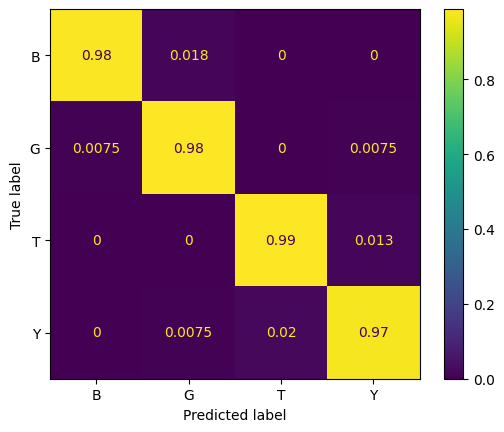

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_predicted = model.predict(x_test_filter[..., np.newaxis])
y_predicted_labels = np.argmax(y_predicted, axis=1)

# Confronta le etichette vere con quelle predette e costruisce una matrice di confusione
# normalize='true': ogni riga somma a 1 -> percentuali per classe vera
confusionMatrix = confusion_matrix(y_test_filter, y_predicted_labels, normalize="true")

# accuracy per classe: diagonale della matrice normalizzata
for lbl, acc in zip(SELECTED_LABELS, confusionMatrix.diagonal()):
    print(f"Accuracy {lbl}: {acc:.2%}")

# Grafico della matrice di confusione (righe = classe vera, colonne = classe predetta)
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusionMatrix, display_labels=SELECTED_LABELS
)
disp.plot()
plt.show()

# Individuazione Griglia e riconoscimento celle

In [ ]:
import sys, os

sys.path.append(os.path.abspath(".."))

# Pipeline di individuazione griglia e riconoscimento celle,
# spostata nel package grid_recognition/
from grid_recognition import (
    preparation,
    extract_grid_mask,
    detect_segments,
    classify_segments,
    segment_representative_position,
    cluster_lines_by_position,
    filter_clusters_by_span,
    build_grid_lines,
    compute_intersections,
    extract_all_cells,
    predict_grid,
    draw_all_segments,
    draw_grid_lines,
    draw_intersections,
    visualize_cells,
    print_matrix,
)

In [ ]:
# Carica l'immagine, la converte in scala di grigi e ne estrae i contorni (Canny)
print("STEP 1: Preprocessing")
img, gray, edges = preparation("../grid_imgs/image2.png", show=True)

# Rileva segmenti di linee con Hough, classificandoli in orizzontali e verticali
print("\nSTEP 2: Rilevamento segmenti Hough")
grid_mask = extract_grid_mask(gray, show=True)
segs = detect_segments(grid_mask)

# Classifica i segmenti in orizzontali e verticali, scartando quelli obliqui
print("\nSTEP 3: Classificazione H/V")
horiz, vert = classify_segments(segs)

# Mostra tutti i segmenti rilevati, evidenziando quelli orizzontali e verticali
draw_all_segments(img, segs, horiz, vert)

# Calcola la coordinata trasversale (X o Y) di ogni singolo frammento
print("\nSTEP 4: Clustering e linee medie")
horiz_cl = cluster_lines_by_position(segment_representative_position(horiz, "y"))
vert_cl = cluster_lines_by_position(segment_representative_position(vert, "x"))
horiz_cl, vert_cl = filter_clusters_by_span(horiz_cl, vert_cl)
h_lines, v_lines = build_grid_lines(horiz_cl, vert_cl, img.shape)
draw_grid_lines(img, h_lines, v_lines)

# Calcola le intersezioni tra le linee della griglia per ottenere i vertici delle celle
print("\nSTEP 5: Calcolo intersezioni")
pts = compute_intersections(h_lines, v_lines)
draw_intersections(img, pts)

# Calcola quante celle ci sono in totale (es. se ci sono 4 linee verticali, ci sono 3 colonne)
print(f"Griglia: {pts.shape[0] - 1} righe × {pts.shape[1] - 1} colonne")

# 6. Estrazione + classificazione
print("\nSTEP 6: Estrazione celle e classificazione")
# Ritaglia, raddrizza in prospettiva ed elimina i bordi neri da ogni quadratino
cells_2d = extract_all_cells(gray, pts)
visualize_cells(cells_2d)

# Passa ogni singola immagine ritagliata alla funzione che si interfaccia con la rete neurale
matrix = predict_grid(cells_2d, model)
print_matrix(matrix)